Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

Loading Data

In [3]:
# Load the raw dataset
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
print("Raw Dataset Shape:", df.shape)
display(df.head())

Raw Dataset Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Exploratory Data Analysis (EDA)

In [4]:
# Temporary fill of missing target values for EDA plotting
df_eda = df.copy()
df_eda['Sleep Disorder'] = df_eda['Sleep Disorder'].fillna('None')

C:\Users\Ishan\AppData\Local\Temp\ipykernel_12700\940037100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='Sleep Disorder', palette='Set2')


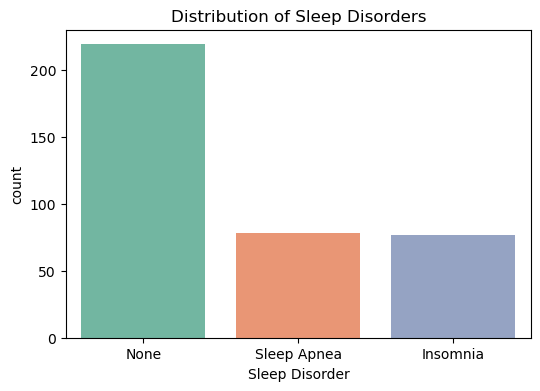

In [5]:
# Plot 1: Distribution of Sleep Disorders
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x='Sleep Disorder', palette='Set2')
plt.title('Distribution of Sleep Disorders')
plt.show()

C:\Users\Ishan\AppData\Local\Temp\ipykernel_12700\2199885032.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Sleep Disorder', y='Stress Level', palette='Set3')


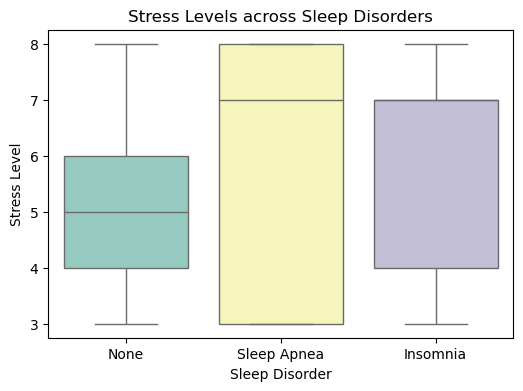

In [6]:
# Plot 2: Stress Level vs Sleep Disorder
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_eda, x='Sleep Disorder', y='Stress Level', palette='Set3')
plt.title('Stress Levels across Sleep Disorders')
plt.show()

Data Preprocessing & Exporting Clean Data

In [7]:
# 1. Drop unnecessary identifier
df = df.drop('Person ID', axis=1)

In [8]:
# 2. Split 'Blood Pressure' into two numerical columns
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic'] = pd.to_numeric(df['Systolic'])
df['Diastolic'] = pd.to_numeric(df['Diastolic'])
df = df.drop('Blood Pressure', axis=1)

In [9]:
# 3. Fill Missing Values
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

In [10]:
# 4. Encode Text columns to Numbers
le = LabelEncoder()
categorical_cols = ['Gender', 'Occupation', 'BMI Category']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
# Encode Target Variable (0=Insomnia, 1=None, 2=Sleep Apnea)
target_le = LabelEncoder()
df['Sleep Disorder'] = target_le.fit_transform(df['Sleep Disorder'])

In [12]:
# 5. Scale Numerical Variables
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 
                  'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [13]:
# 6. Save the preprocessed data for the team!
df.to_csv('processed_sleep_data.csv', index=False)
print("Preprocessing complete! Clean data saved as 'processed_sleep_data.csv'.")
print("Target Class Mapping:", list(target_le.classes_))

Preprocessing complete! Clean data saved as 'processed_sleep_data.csv'.
Target Class Mapping: ['Insomnia', 'None', 'Sleep Apnea']
